In [1]:
print (ord('杨'))

26472


In [2]:
print (chr(26472))

杨


In [3]:
print (repr(chr(0)))

'\x00'


In [4]:
print("this is a test" + chr(0) + "string")

this is a test string


In [5]:
test_string = "hello! こんにちは!"
utf8_encoded = test_string.encode("utf-8")
print (utf8_encoded)

b'hello! \xe3\x81\x93\xe3\x82\x93\xe3\x81\xab\xe3\x81\xa1\xe3\x81\xaf!'


In [6]:
print (type(utf8_encoded))

<class 'bytes'>


In [7]:
# 打印出来来是10进制数字数组
print (list(utf8_encoded))

[104, 101, 108, 108, 111, 33, 32, 227, 129, 147, 227, 130, 147, 227, 129, 171, 227, 129, 161, 227, 129, 175, 33]


怎么算出来的？

十六进制是 16进制，所以：

e3 = e × 16¹ + 3 × 16⁰

其中：

e = 14（因为 a=10, b=11, ..., e=14）

所以：

= 14 × 16 + 3
= 224 + 3
= 227

In [8]:
print (len(utf8_encoded))

23


In [9]:
print (utf8_encoded.decode("utf-8"))

hello! こんにちは!


In [10]:
def decode_utf8_bytes_to_str_wrong(bytestring: bytes):
    return "".join([bytes([b]).decode("utf-8") for b in bytestring])

In [11]:
decode_utf8_bytes_to_str_wrong("HELLO".encode("utf-8"))

'HELLO'

In [12]:
decode_utf8_bytes_to_str_wrong("你是谁".encode("utf-8"))

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xe4 in position 0: unexpected end of data

# BPE Training Example

In [13]:
# 论文原始 toy vocab（词已经被拆成字符序列）
vocab = {
    'l o w </w>'      : 5,
    'l o w e r </w>'  : 2,
    'n e w e s t </w>': 6,
    'w i d e s t </w>': 3,
}

In [14]:
for word, freq in vocab.items():
    print (f"freq={freq}, word_repr='{word}'")

freq=5, word_repr='l o w </w>'
freq=2, word_repr='l o w e r </w>'
freq=6, word_repr='n e w e s t </w>'
freq=3, word_repr='w i d e s t </w>'


## 实现get_stats

In [15]:
import collections

def get_stats(vocab):
    pairs = collections.defaultdict(int)
    for word, freq in vocab.items():
        symbols = word.split()
        for i in range(len(symbols) - 1):
            pairs[symbols[i], symbols[i+1]] += freq
    return pairs

In [16]:
pairs = get_stats(vocab)

In [17]:
for pair, freq in sorted(pairs.items(), key=lambda x: -x[1]):
    print(f"freq={freq}, pair={pair}")

freq=9, pair=('e', 's')
freq=9, pair=('s', 't')
freq=9, pair=('t', '</w>')
freq=8, pair=('w', 'e')
freq=7, pair=('l', 'o')
freq=7, pair=('o', 'w')
freq=6, pair=('n', 'e')
freq=6, pair=('e', 'w')
freq=5, pair=('w', '</w>')
freq=3, pair=('w', 'i')
freq=3, pair=('i', 'd')
freq=3, pair=('d', 'e')
freq=2, pair=('e', 'r')
freq=2, pair=('r', '</w>')


## 实现merge_vocab

In [18]:
import re

def merge_vocab(pair, v_in):
    v_out = {}
    bigram = re.escape(' '.join(pair))
    p = re.compile(r'(?<!\S)' + bigram + r'(?!\S)')
    for word in v_in:
        w_out = p.sub(''.join(pair), word)
        v_out[w_out] = v_in[word]
    return v_out

In [19]:
best = max(pairs, key=pairs.get)

In [20]:
print(f"best pair: {best}")

best pair: ('e', 's')


In [21]:
vocab = merge_vocab(best, vocab)

In [22]:
for word, freq in vocab.items():
    print(f"freq={freq}, word_repr='{word}'")

freq=5, word_repr='l o w </w>'
freq=2, word_repr='l o w e r </w>'
freq=6, word_repr='n e w es t </w>'
freq=3, word_repr='w i d es t </w>'


## 主循环

In [23]:
# 训练，同时保存 merge rules
num_merges = 10
merge_rules = []                          # ← 新增：记录每轮的 best pair

for i in range(num_merges):
    pairs = get_stats(vocab)
    best = max(pairs, key=pairs.get)
    vocab = merge_vocab(best, vocab)
    merge_rules.append(best)              # ← 新增

print("学到的 merge rules（顺序很重要）：")
for i, rule in enumerate(merge_rules):
    print(f"  {i+1:>2}. {rule[0]} + {rule[1]} → {''.join(rule)}")

学到的 merge rules（顺序很重要）：
   1. es + t → est
   2. est + </w> → est</w>
   3. l + o → lo
   4. lo + w → low
   5. n + e → ne
   6. ne + w → new
   7. new + est</w> → newest</w>
   8. low + </w> → low</w>
   9. w + i → wi
  10. wi + d → wid


## 实现encode

In [24]:
def encode(word, merge_rules):
    # 第一步: 拆成字符，词尾加 </w>
    symbols = list(word) + ['</w>']

    # 第二步: 按顺序应用每条 merge rule
    for rule in merge_rules:
        i = 0
        while i < len(symbols) - 1:
            if symbols[i] == rule[0] and symbols[i+1] == rule[1]:
                symbols = symbols[:i] + [''.join(rule)] + symbols[i+2:]
            else:
                i += 1
    return symbols

In [25]:
for test_word in ['low', 'lower', 'newest', 'widest']:
    tokens = encode(test_word, merge_rules)
    print(f"{test_word:>10} → {tokens}")

       low → ['low</w>']
     lower → ['low', 'e', 'r', '</w>']
    newest → ['new', 'e', 's', 't', '</w>']
    widest → ['wid', 'e', 's', 't', '</w>']


In [26]:
for test_word in ['newer', 'lowest', 'wild']:
    tokens = encode(test_word, merge_rules)
    print(f"{test_word:>10} → {tokens}")

     newer → ['new', 'e', 'r', '</w>']
    lowest → ['low', 'e', 's', 't', '</w>']
      wild → ['wi', 'l', 'd', '</w>']


In [27]:
print(merge_rules)

[('es', 't'), ('est', '</w>'), ('l', 'o'), ('lo', 'w'), ('n', 'e'), ('ne', 'w'), ('new', 'est</w>'), ('low', '</w>'), ('w', 'i'), ('wi', 'd')]


## 完整算法

In [28]:
# 论文原始 toy vocab（词已经被拆成字符序列）
vocab = {
    'l o w </w>'      : 5,
    'l o w e r </w>'  : 2,
    'n e w e s t </w>': 6,
    'w i d e s t </w>': 3,
}

import collections

def get_stats(vocab):
    pairs = collections.defaultdict(int)
    for word, freq in vocab.items():
        symbols = word.split()
        for i in range(len(symbols) - 1):
            pairs[symbols[i], symbols[i+1]] += freq
    return pairs

import re

def merge_vocab(pair, v_in):
    v_out = {}
    bigram = re.escape(' '.join(pair))
    p = re.compile(r'(?<!\S)' + bigram + r'(?!\S)')
    for word in v_in:
        w_out = p.sub(''.join(pair), word)
        v_out[w_out] = v_in[word]
    return v_out

# 训练，同时保存 merge rules
num_merges = 12
merge_rules = []                          # ← 新增：记录每轮的 best pair

for i in range(num_merges):
    pairs = get_stats(vocab)
    best = max(pairs, key=pairs.get)
    vocab = merge_vocab(best, vocab)
    merge_rules.append(best)              # ← 新增

print("学到的 merge rules（顺序很重要）：")
for i, rule in enumerate(merge_rules):
    print(f"  {i+1:>2}. {rule[0]} + {rule[1]} → {''.join(rule)}")

学到的 merge rules（顺序很重要）：
   1. e + s → es
   2. es + t → est
   3. est + </w> → est</w>
   4. l + o → lo
   5. lo + w → low
   6. n + e → ne
   7. ne + w → new
   8. new + est</w> → newest</w>
   9. low + </w> → low</w>
  10. w + i → wi
  11. wi + d → wid
  12. wid + est</w> → widest</w>


In [29]:
def encode(word, merge_rules):
    # 第一步: 拆成字符，词尾加 </w>
    symbols = list(word) + ['</w>']

    # 第二步: 按顺序应用每条 merge rule
    for rule in merge_rules:
        i = 0
        while i < len(symbols) - 1:
            if symbols[i] == rule[0] and symbols[i+1] == rule[1]:
                symbols = symbols[:i] + [''.join(rule)] + symbols[i+2:]
            else:
                i += 1
    return symbols

In [30]:
for test_word in ['newer', 'lowest', 'wild']:
    tokens = encode(test_word, merge_rules)
    print(f"{test_word:>10} → {tokens}")

for test_word in ['low', 'lower', 'newest', 'widest']:
    tokens = encode(test_word, merge_rules)
    print(f"{test_word:>10} → {tokens}")

     newer → ['new', 'e', 'r', '</w>']
    lowest → ['low', 'est</w>']
      wild → ['wi', 'l', 'd', '</w>']
       low → ['low</w>']
     lower → ['low', 'e', 'r', '</w>']
    newest → ['newest</w>']
    widest → ['widest</w>']


## 完整的BPE实现

In [31]:
import re, collections

class BPETokenizer:
    def __init__(self, num_merges):
        self.num_merges = num_merges
        self.merge_rules = []
        self.vocab = {}

    def train(self, corpus):
        """从原始文本语料训练，建立初始字符词表并学习 merge rules"""
        # 统计词频，初始化为字符序列
        word_freq = collections.defaultdict(int)
        for word in corpus.split():
            word_freq[word] += 1

        self.vocab = {
            ' '.join(list(word)) + ' </w>': freq
            for word, freq in word_freq.items()
        }

        # 训练循环
        for i in range(self.num_merges):
            pairs = self._get_stats()
            if not pairs:
                break
            best = max(pairs, key=pairs.get)
            self._merge_vocab(best)
            self.merge_rules.append(best)

        return self

    def encode(self, word):
        """把一个词编码为 subword token 列表"""
        symbols = list(word) + ['</w>']
        for rule in self.merge_rules:
            i = 0
            while i < len(symbols) - 1:
                if symbols[i] == rule[0] and symbols[i+1] == rule[1]:
                    symbols = symbols[:i] + [''.join(rule)] + symbols[i+2:]
                else:
                    i += 1
        return symbols

    def tokenize(self, text):
        """对整段文本分词，返回所有 token"""
        tokens = []
        for word in text.split():
            tokens.extend(self.encode(word))
        return tokens

    def _get_stats(self):
        pairs = collections.defaultdict(int)
        for word, freq in self.vocab.items():
            symbols = word.split()
            for i in range(len(symbols) - 1):
                pairs[symbols[i], symbols[i+1]] += freq
        return pairs

    def _merge_vocab(self, pair):
        new_vocab = {}
        bigram = re.escape(' '.join(pair))
        p = re.compile(r'(?<!\S)' + bigram + r'(?!\S)')
        for word in self.vocab:
            w_out = p.sub(''.join(pair), word)
            new_vocab[w_out] = self.vocab[word]
        self.vocab = new_vocab


# ── 测试 ──────────────────────────────────────────────
corpus = "low low low low low lower lower newest newest newest newest newest newest widest widest widest"

tokenizer = BPETokenizer(num_merges=3)
tokenizer.train(corpus)

print("── merge rules ──")
for i, rule in enumerate(tokenizer.merge_rules):
    print(f"  {i+1:>2}. {rule[0]} + {rule[1]} → {''.join(rule)}")

print("\n── encode ──")
for word in ['low', 'lower', 'newest', 'widest', 'newer', 'lowest', 'wild']:
    print(f"  {word:>10} → {tokenizer.encode(word)}")

print("\n── tokenize ──")
text = "the newest low widest"
print(f"  input : '{text}'")
print(f"  tokens: {tokenizer.tokenize(text)}")

── merge rules ──
   1. e + s → es
   2. es + t → est
   3. est + </w> → est</w>

── encode ──
         low → ['l', 'o', 'w', '</w>']
       lower → ['l', 'o', 'w', 'e', 'r', '</w>']
      newest → ['n', 'e', 'w', 'est</w>']
      widest → ['w', 'i', 'd', 'est</w>']
       newer → ['n', 'e', 'w', 'e', 'r', '</w>']
      lowest → ['l', 'o', 'w', 'est</w>']
        wild → ['w', 'i', 'l', 'd', '</w>']

── tokenize ──
  input : 'the newest low widest'
  tokens: ['t', 'h', 'e', '</w>', 'n', 'e', 'w', 'est</w>', 'l', 'o', 'w', '</w>', 'w', 'i', 'd', 'est</w>']


## ResNet理解

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

### ── 超参数 ─────────────────────────────────────────────

In [33]:
EPOCHS      = 20
BATCH_SIZE  = 128
LR          = 0.1
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {DEVICE}")

使用设备: cuda


### ── 数据集（CIFAR-10）───────────────────────────────────

In [34]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])
 
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=transform_train)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                         download=True, transform=transform_test)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE,
                                           shuffle=True,  num_workers=2)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=BATCH_SIZE,
                                           shuffle=False, num_workers=2)

100%|████████████████████████████████████████████████████████████████████████████| 170M/170M [00:52<00:00, 3.26MB/s]


Extracting ./data\cifar-10-python.tar.gz to ./data
Files already downloaded and verified


### ── 网络定义 ─────────────────────────────────────────────

In [35]:
class PlainBlock(nn.Module):
    """普通残差块（无 skip connection）"""
    def __init__(self, channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
        )
 
    def forward(self, x):
        return self.net(x)          # 无残差ÆÆ

In [36]:
class ResBlock(nn.Module):
    """标准残差块（有 skip connection）"""
    def __init__(self, channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU(inplace=True)
 
    def forward(self, x):
        return self.relu(self.net(x) + x)   # 残差连接

In [37]:
def build_network(block_type, num_blocks, channels=64):
    """
    通用网络构建器
    block_type : PlainBlock 或 ResBlock
    num_blocks : 堆叠的 Block 数量
    """
    layers = [
        nn.Conv2d(3, channels, 3, padding=1, bias=False),
        nn.BatchNorm2d(channels),
        nn.ReLU(inplace=True),
    ]
    for _ in range(num_blocks):
        layers.append(block_type(channels))
 
    layers += [
        nn.AdaptiveAvgPool2d(1),
        nn.Flatten(),
        nn.Linear(channels, 10),
    ]
    return nn.Sequential(*layers)

In [38]:
# 三个对照网络
models = {
    "Plain-10层":    build_network(PlainBlock, num_blocks=4),
    "Plain-20层":    build_network(PlainBlock, num_blocks=9),
    "ResNet-20层":   build_network(ResBlock,   num_blocks=9),
}


训练: Plain-10层
  Epoch  1/20 | train_loss=1.679 | val_loss=1.599 | val_acc=42.2%
  Epoch  5/20 | train_loss=0.927 | val_loss=1.059 | val_acc=63.4%
  Epoch 10/20 | train_loss=0.658 | val_loss=0.770 | val_acc=73.2%
  Epoch 15/20 | train_loss=0.437 | val_loss=0.523 | val_acc=82.0%
  Epoch 20/20 | train_loss=0.280 | val_loss=0.398 | val_acc=86.6%

训练: Plain-20层
  Epoch  1/20 | train_loss=1.825 | val_loss=1.751 | val_acc=32.0%
  Epoch  5/20 | train_loss=1.143 | val_loss=1.365 | val_acc=50.2%
  Epoch 10/20 | train_loss=0.842 | val_loss=1.383 | val_acc=58.7%
  Epoch 15/20 | train_loss=0.594 | val_loss=0.990 | val_acc=68.8%
  Epoch 20/20 | train_loss=0.388 | val_loss=0.488 | val_acc=83.5%

训练: ResNet-20层
  Epoch  1/20 | train_loss=1.888 | val_loss=1.760 | val_acc=36.8%
  Epoch  5/20 | train_loss=0.949 | val_loss=1.259 | val_acc=57.6%
  Epoch 10/20 | train_loss=0.615 | val_loss=0.957 | val_acc=70.8%
  Epoch 15/20 | train_loss=0.379 | val_loss=0.520 | val_acc=82.7%
  Epoch 20/20 | train_loss=0.2

C:\Users\WIN11\AppData\Local\Temp\ipykernel_32392\3329858725.py:128: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\WIN11\AppData\Local\Temp\ipykernel_32392\3329858725.py:128: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\WIN11\AppData\Local\Temp\ipykernel_32392\3329858725.py:128: UserWarning: Glyph 23618 (\N{CJK UNIFIED IDEOGRAPH-5C42}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\WIN11\AppData\Local\Temp\ipykernel_32392\3329858725.py:128: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\WIN11\AppData\Local\Temp\ipykernel_32392\3329858725.py:128: UserWarning: Glyph 35777 (\N{CJK UNIFIED IDEOGRAPH-8BC1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\WIN11\AppData\Local\Temp\ipykernel_32392\3329858725.py:128: UserWarning: Glyph 38


图表已保存为 residual_experiment.png

模型                最终val_loss    最终val_acc
Plain-10层             0.3982       86.59%
Plain-20层             0.4883       83.47%
ResNet-20层            0.3407       88.81%


D:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23618 (\N{CJK UNIFIED IDEOGRAPH-5C42}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35777 (\N{CJK UNIFIED IDEOGRAPH-8BC1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda\Lib\site

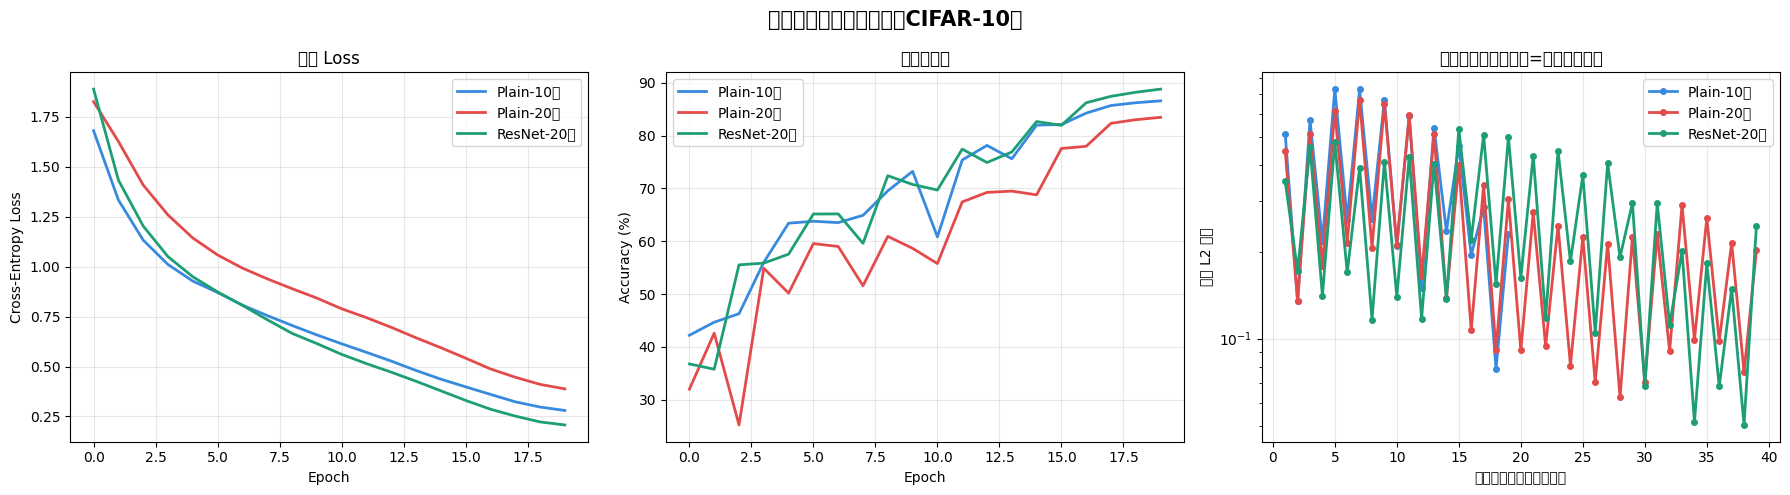

In [39]:
# ── 训练 & 评估函数 ──────────────────────────────────────
 
def train_epoch(model, optimizer, criterion):
    model.train()
    total_loss = 0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(inputs), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(trainloader)
 
 
def evaluate(model, criterion):
    model.eval()
    correct, total, total_loss = 0, 0, 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            total_loss += criterion(outputs, labels).item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / len(testloader), correct / total
 
 
def get_gradient_norms(model):
    """收集每个有梯度的层的梯度 L2 范数"""
    norms = []
    for name, param in model.named_parameters():
        if param.grad is not None and 'weight' in name:
            norms.append((name, param.grad.norm().item()))
    return norms
 
 
# ── 主训练循环 ───────────────────────────────────────────
 
history   = {name: {"train_loss": [], "val_loss": [], "val_acc": []}
             for name in models}
grad_data = {}   # 最后一个 epoch 的梯度范数
 
criterion = nn.CrossEntropyLoss()
 
for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"训练: {name}")
    print(f"{'='*50}")
 
    model = model.to(DEVICE)
    optimizer = optim.SGD(model.parameters(), lr=LR,
                          momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
 
    for epoch in range(EPOCHS):
        train_loss = train_epoch(model, optimizer, criterion)
        val_loss, val_acc = evaluate(model, criterion)
        scheduler.step()
 
        history[name]["train_loss"].append(train_loss)
        history[name]["val_loss"].append(val_loss)
        history[name]["val_acc"].append(val_acc)
 
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:2d}/{EPOCHS} | "
                  f"train_loss={train_loss:.3f} | "
                  f"val_loss={val_loss:.3f} | "
                  f"val_acc={val_acc*100:.1f}%")
 
    # 收集最终梯度（跑一个 mini-batch）
    model.train()
    inputs, labels = next(iter(trainloader))
    inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
    optimizer.zero_grad()
    loss = criterion(model(inputs), labels)
    loss.backward()
    grad_data[name] = get_gradient_norms(model)
 
# ── 可视化 ───────────────────────────────────────────────
 
colors = {
    "Plain-10层":  "#378ADD",
    "Plain-20层":  "#E24B4A",
    "ResNet-20层": "#1D9E75",
}
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("残差连接效果实验对比（CIFAR-10）", fontsize=15, fontweight='bold')
 
# ── 图1：训练 Loss ──
ax = axes[0]
for name, h in history.items():
    ax.plot(h["train_loss"], label=name, color=colors[name], linewidth=2)
ax.set_title("训练 Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss")
ax.legend()
ax.grid(alpha=0.3)
 
# ── 图2：验证精度 ──
ax = axes[1]
for name, h in history.items():
    ax.plot([v * 100 for v in h["val_acc"]],
            label=name, color=colors[name], linewidth=2)
ax.set_title("验证集精度")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy (%)")
ax.legend()
ax.grid(alpha=0.3)
 
# ── 图3：各层梯度范数（梯度消失可视化）──
ax = axes[2]
for name, norms in grad_data.items():
    # 从输出层往输入层排列（越靠左越深）
    layer_ids = list(range(len(norms), 0, -1))
    values    = [v for _, v in norms][::-1]
    ax.plot(layer_ids, values, marker='o', markersize=4,
            label=name, color=colors[name], linewidth=2)
 
ax.set_title("各层梯度范数（靠左=靠近输入层）")
ax.set_xlabel("层索引（从输出到输入）")
ax.set_ylabel("梯度 L2 范数")
ax.set_yscale("log")   # 对数坐标更直观
ax.legend()
ax.grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig("residual_experiment.png", dpi=150, bbox_inches='tight')
print("\n图表已保存为 residual_experiment.png")
 
# ── 打印最终对比表 ──────────────────────────────────────
print("\n" + "="*55)
print(f"{'模型':<15} {'最终val_loss':>12} {'最终val_acc':>12}")
print("="*55)
for name, h in history.items():
    print(f"{name:<15} {h['val_loss'][-1]:>12.4f} {h['val_acc'][-1]*100:>11.2f}%")
print("="*55)